In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [2]:
pd.set_option("display.max_rows", 999)
pd.set_option("display.max_columns", 999)

# Preamble

This notebook will likely cover: 
- data loading + formatting issues (Parquet vs CSV, timestamp parsing)
- null analysis (counts, percentages)
- schema inspection: dtypes, shape, value counts for categorical features
- standard descriptive statistics
- cleaned data file outputs fed as inputs to modelling and plotting notebooks

### Loading and Inspecting

In [3]:
pue_c_df = pd.read_parquet("/Users/toelou/Desktop/code/EnvyPrep/NLR_HPC_Facility_PUE/data/esif.influx.buildingData.PUE.combined.parquet") #, encoding = "utf-8-sig")
pue_oc_df = pd.read_parquet("/Users/toelou/Desktop/code/EnvyPrep/NLR_HPC_Facility_PUE/data/esif.influx.buildingData.outside.combined.parquet") #, encoding = "utf-8-sig")

In [4]:
print(f'There are {0} rows in the dataframe and {1} columns in the dataframe'.format(pue_c_df.shape[0], pue_c_df.shape[1]))
print(f'\nThese are the data types:\n')
print(pue_c_df.dtypes)
print(f'There are {0} rows in the dataframe and {1} columns in the dataframe'.format(pue_oc_df.shape[0], pue_oc_df.shape[1]))
print(f'\nThese are the data types:\n')
print(pue_oc_df.dtypes)

There are 0 rows in the dataframe and 1 columns in the dataframe

These are the data types:

tags                         object
ts                   datetime64[us]
cooling_kw                  float64
energy_reuse                float64
ere                         float64
hvac_kw                     float64
it_power_kw                 float64
plug_and_light_kw           float64
pue                         float64
pump_kw                     float64
day                           int64
dtype: object
There are 0 rows in the dataframe and 1 columns in the dataframe

These are the data types:

tags                            object
ts                      datetime64[us]
outdoor_air_humidity           float64
outdoor_air_temp               float64
unit                            object
day                              int64
dtype: object


In [5]:
pue_c_df.head()

,tags,ts,cooling_kw,energy_reuse,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day
0,None,2015-11-10 03:00:01,NaN,NaN,0.827,NaN,NaN,NaN,1.035,NaN,10
1,None,2015-11-10 03:01:08,NaN,NaN,0.828,NaN,NaN,NaN,1.035,NaN,10
2,None,2015-11-10 03:05:02,NaN,NaN,0.819,NaN,NaN,NaN,1.034,NaN,10
3,None,2015-11-10 03:09:56,NaN,NaN,0.830,NaN,NaN,NaN,1.028,NaN,10
4,None,2015-11-10 03:15:47,NaN,NaN,0.820,NaN,NaN,NaN,1.027,NaN,10


In [6]:
pue_oc_df.head()

,tags,ts,outdoor_air_humidity,outdoor_air_temp,unit,day
0,None,1970-01-01 00:00:00,0.0,0.0,None,1
1,None,2016-06-12 06:00:18,64.3,62.7,None,12
2,None,2016-06-12 06:01:16,64.3,62.7,None,12
3,None,2016-06-12 06:02:17,63.5,62.8,None,12
4,None,2016-06-12 06:03:16,63.8,62.8,None,12


In [7]:
pue_c_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4569543 entries, 0 to 4569542
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   tags               object        
 1   ts                 datetime64[us]
 2   cooling_kw         float64       
 3   energy_reuse       float64       
 4   ere                float64       
 5   hvac_kw            float64       
 6   it_power_kw        float64       
 7   plug_and_light_kw  float64       
 8   pue                float64       
 9   pump_kw            float64       
 10  day                int64         
dtypes: datetime64[us](1), float64(8), int64(1), object(1)
memory usage: 383.5+ MB


In [8]:
pue_oc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4034917 entries, 0 to 4034916
Data columns (total 6 columns):
 #   Column                Dtype         
---  ------                -----         
 0   tags                  object        
 1   ts                    datetime64[us]
 2   outdoor_air_humidity  float64       
 3   outdoor_air_temp      float64       
 4   unit                  object        
 5   day                   int64         
dtypes: datetime64[us](1), float64(2), int64(1), object(2)
memory usage: 184.7+ MB


In [9]:
pue_c_df.describe()

,ts,cooling_kw,energy_reuse,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day
count,4569543,4.433041e+06,1.006817e+06,4.569531e+06,4.433033e+06,4.433055e+06,4.433057e+06,4.568744e+06,4.433056e+06,4.569543e+06
mean,2021-01-06 10:35:14.158934,1.148993e+01,-5.892246e-01,1.010586e+00,3.144624e+01,1.505295e+03,3.473162e+00,1.044877e+00,1.971686e+01,1.580712e+01
min,2015-11-10 03:00:01,-3.330000e+00,-1.630889e+02,-4.260800e+01,-6.940000e+00,1.000000e-01,0.000000e+00,-4.260800e+01,-4.000000e+00,1.000000e+00
25%,2018-10-31 02:38:01.500000,6.470000e+00,-1.163467e+00,9.630000e-01,8.240000e+00,9.665200e+02,2.004200e+00,1.027000e+00,8.310000e+00,8.000000e+00
50%,2021-01-18 22:21:32,8.070000e+00,3.018330e-01,1.020402e+00,9.370000e+00,1.200500e+03,3.200000e+00,1.033000e+00,1.322000e+01,1.600000e+01
75%,2023-05-27 23:52:38,1.587000e+01,5.370966e-01,1.040000e+00,1.081000e+01,1.827420e+03,4.860222e+00,1.047000e+00,3.536800e+01,2.300000e+01
max,2025-08-29 04:35:08.461000,2.516370e+03,9.766888e+02,5.473920e+02,5.071570e+03,3.921329e+03,1.383000e+01,5.283001e+02,9.326400e+01,3.100000e+01
std,NaN,9.985638e+00,7.161416e+00,1.491917e+00,5.339631e+01,7.782770e+02,2.008326e+00,1.003119e+00,1.455072e+01,8.774443e+00


In [10]:
pue_oc_df.describe()

,ts,outdoor_air_humidity,outdoor_air_temp,day
count,4034917,4.033936e+06,4.033840e+06,4.034917e+06
mean,2021-02-25 04:19:38.781152,4.203863e+01,5.413383e+01,1.580258e+01
min,1970-01-01 00:00:00,0.000000e+00,-3.940000e+01,1.000000e+00
25%,2018-07-20 18:55:27,2.916740e+01,3.987638e+01,8.000000e+00
50%,2021-03-18 17:17:31,3.859300e+01,5.465083e+01,1.600000e+01
75%,2023-08-28 05:45:33,5.230000e+01,6.890000e+01,2.300000e+01
max,2025-08-29 18:51:19.790000,1.000000e+02,1.042280e+02,3.100000e+01
std,NaN,1.711230e+01,1.929648e+01,8.764759e+00


### Selection & Data Cleaning

In [11]:
# Checking for total null values -- whether or not I have to do data imputation
pue_c_df.isnull().sum()

tags                 4569543
ts                         0
cooling_kw            136502
energy_reuse         3562726
ere                       12
hvac_kw               136510
it_power_kw           136488
plug_and_light_kw     136486
pue                      799
pump_kw               136487
day                        0
dtype: int64

In [12]:
# Checking for total null values -- whether or not I have to do data imputation
pue_oc_df.isnull().sum()

tags                    4034917
ts                            0
outdoor_air_humidity        981
outdoor_air_temp           1077
unit                    3306781
day                           0
dtype: int64

In [13]:
pue_oc_df.value_counts()

Series([], Name: count, dtype: int64)

In [14]:
pue_c_df.value_counts()

Series([], Name: count, dtype: int64)

In [15]:
pue_c_df.nunique()

tags                       0
ts                   4569543
cooling_kw            328107
energy_reuse          897509
ere                  1010656
hvac_kw               785428
it_power_kw          1183262
plug_and_light_kw       7901
pue                  1007208
pump_kw               161201
day                       31
dtype: int64

In [16]:
pue_oc_df.nunique()

tags                          0
ts                      4034917
outdoor_air_humidity    1039205
outdoor_air_temp         960639
unit                          1
day                          31
dtype: int64

In [17]:
pue_oc_df['unit'] = pue_oc_df['unit'].astype('string')

In [18]:
# Null percecntage
print(pue_oc_df['unit'].isnull().sum() / len(pue_oc_df) * 100)

81.95412693743143


# Note

At the prodution level ofr HPC telemetry systems, sometimes correlated nulls across multiple sensors at the same timestamp indicates a collection layer failure not an individual instrument failure. In fact, this is likely a snesor calibration issue/outage/sensor dropout pattern. When data collection systems go down, it drops all metrics simultaneously rather than losing individual sensors independently. 

Imputation doesn't work for individual sensors and remediation is different for them. Better to drop time windows entirely or to flag them as a system outage and treat them as a separate category.

In [19]:
# Full breakdown
print(pue_oc_df['unit'].value_counts(dropna=False))

unit
<NA>       3306781
outside     728136
Name: count, dtype: Int64


In [20]:
# Cooling_kw Null percentage 
null_count = pue_c_df['cooling_kw'].isnull().sum()
total_rows = len(pue_c_df['cooling_kw'])
null_pct = null_count / total_rows
print(null_pct * 100)

2.9872133821697266


In [21]:
# hvac_kw Null percentage
hvac_null_count = pue_c_df['hvac_kw'].isnull().sum()
total_rows = len(pue_c_df['hvac_kw'])
null_ct = null_count / total_rows
print(null_ct * 100)

2.9872133821697266


In [22]:
# it_power_kw Null percecntage
it_power_kw_null_count = pue_c_df['it_power_kw'].isnull().sum()
total_rows = len(pue_c_df['it_power_kw'])
null_t = it_power_kw_null_count / total_rows
print(null_ct * 100)

2.9872133821697266


In [23]:
# check if nulls occur on the same rows
cooling_null_idx = pue_c_df['cooling_kw'].isnull()
hvac_null_idx = pue_c_df['hvac_kw'].isnull()
it_null_idx = pue_c_df['it_power_kw'].isnull()

print((cooling_null_idx == hvac_null_idx).all())
print((cooling_null_idx == it_null_idx).all())

False
False


In [24]:
# How many rows have nulls in one but not the others
cooling_only = cooling_null_idx & ~hvac_null_idx
hvac_only = hvac_null_idx & ~cooling_null_idx
it_only = it_null_idx & ~cooling_null_idx

print(f'Cooling null but hvac not: {cooling_only.sum()}')
print(f'Hvac null but cooling not: {hvac_only.sum()}')
print(f'IT power null but cooling not: {it_only.sum()}')

# How many rows have ALL three null simultaneously
all_three = cooling_null_idx & hvac_null_idx & it_null_idx
print(f'All three null same row: {all_three.sum()}')

# How many rows have ANY null
any_null = cooling_null_idx | hvac_null_idx | it_null_idx
print(f'Any null across three columns: {any_null.sum()}')

Cooling null but hvac not: 12
Hvac null but cooling not: 20
IT power null but cooling not: 1
All three null same row: 136487
Any null across three columns: 136523


In [25]:
# plug_and_light_kw Null percecntage
plug_and_light_kw_null_count = pue_c_df['plug_and_light_kw'].isnull().sum()
total_rows = len(pue_c_df['plug_and_light_kw'])
null_t = plug_and_light_kw_null_count / total_rows
print(null_ct * 100)

2.9872133821697266


In [26]:
# pump_kw Null percecntage
pump_kw_null_count = pue_c_df['pump_kw'].isnull().sum()
total_rows = len(pue_c_df['pump_kw'])
null_t = pump_kw_null_count / total_rows
print(null_ct * 100)

2.9872133821697266


In [27]:
all_five = (cooling_null_idx & hvac_null_idx & it_null_idx & 
            pue_c_df['plug_and_light_kw'].isnull() & 
            pue_c_df['pump_kw'].isnull())
print(f'All five null same row: {all_five.sum()}')

All five null same row: 136486


# Note

136,486 rows have all five sensors null at once. The remnant 37 rows have partial dropout, between one and four sensors are null while others reported. Basically, almost 100% of the null rows are system-wide telemetry outages, not individual sensor failures. 

I'm dropping ERE (Energy Reuse Effectiveness) because it's probably derived from PUE which creates the multicollinearity problem downstream and predictive power should focus on features that don't suffer from that. I'm dropping rows where all five power metrics have null values because a quick co-occurence analysis script shows 99.97% system-wide dropout indiiating telemtetry outage rather than individual sensor failure. 

In [28]:
pue_c_df.dropna(subset=['cooling_kw', 'hvac_kw', 'it_power_kw', 'plug_and_light_kw', 'pump_kw'], inplace=True)
pue_c_df.reset_index(drop=True, inplace=True)
print(f'Rows remaining: {len(pue_c_df):,}')

Rows remaining: 4,433,020


In [29]:
pue_c_df.head()

,tags,ts,cooling_kw,energy_reuse,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day
0,None,2016-06-12 06:00:18,6.97,NaN,0.958,4.3,804.21,2.37,1.026,7.22,12
1,None,2016-06-12 06:01:16,6.97,NaN,0.958,4.3,803.84,2.37,1.025,6.72,12
2,None,2016-06-12 06:02:17,6.77,NaN,0.956,4.3,800.42,2.39,1.025,6.72,12
3,None,2016-06-12 06:03:16,6.67,NaN,0.959,4.4,804.37,2.37,1.025,6.92,12
4,None,2016-06-12 06:04:17,6.57,NaN,0.961,4.4,801.16,2.37,1.025,6.92,12


In [30]:
pue_oc_df.head()

,tags,ts,outdoor_air_humidity,outdoor_air_temp,unit,day
0,None,1970-01-01 00:00:00,0.0,0.0,<NA>,1
1,None,2016-06-12 06:00:18,64.3,62.7,<NA>,12
2,None,2016-06-12 06:01:16,64.3,62.7,<NA>,12
3,None,2016-06-12 06:02:17,63.5,62.8,<NA>,12
4,None,2016-06-12 06:03:16,63.8,62.8,<NA>,12


In [31]:
pue_c_df['ere'].value_counts()

ere
1.031000    71976
1.032000    71918
1.033000    70267
1.030000    69513
1.034000    66116
            ...  
1.070071        1
1.070513        1
1.070433        1
1.070587        1
1.074807        1
Name: count, Length: 1009918, dtype: int64

In [32]:
pue_c_df['energy_reuse'].value_counts()

energy_reuse
 0.000000    1071
 0.185363      31
 0.171437      31
 0.214956      30
 0.235845      29
             ... 
-1.079038       1
-1.065942       1
-0.779459       1
-0.834761       1
-0.850560       1
Name: count, Length: 897509, dtype: int64

# Note:


**tldr:**
- energy_reuse is being dropped due to sensor quality issues (sentinel zeros, physially impossible negatives, sparse meaningful readings)
- ere is being dropped because it is algebraically related to PUE and it introduces the multicollinearity problem. It would be target leakage, not genuine prediction

**Reasoning:**

**energy_reuse feature**
- So there are 1071 rows with exact values of 0.0, which is a bit weird and is probably a sentinel value and not a real measurement. When energy reuse is atually zero there's a range of near-zero values, not exactly 0.0. This somewhat suggests the system defaulted to 0 when no reading was available and sensors issues are not legitimate readings.

- Also, energy reuse can't be negative because its a ratio of reused energy to total energy. Negative values are physically impossible and confirm sensor or calculation errors in the source system. It seems like this feature is a noisy continuous data with sparse meaningful readings mixed with zeros and impossible negatives, so I'm dropping it.

**ere feature**
- Energy Reuse Effectiveness (ERE) values are clustering pretty tightly around 1.030 and 1.034 with high frequeny counts (71,976 rows at exatly 1.031). This is suspicious precision and suspicious clustering. Real continuous sensor data doesn't produce 71,000 identical readings. This looks like a calculated or derived field being recorded at low precision. 

- ERE is the total facility energy minus the reused energy divided by IT equipment energy. PUE is the total faility energy divided by IT equipment energy. Even though they have the same denominator and basically get omputed from overlapping numerator terms, they're not independent variables. They're algebraic transforms of the same underlying measurements.

- Removing it is helpful because otherwise I'm feeding a model that predicts PUE a derived form of the answer as input. Validation models will look great, but it will be a glorified identity function instead of a useful real predictive model. This is literally the multicollinearity problem.

In [33]:
# Drop the column
pue_c_df.drop(columns=['energy_reuse', 'ere'], inplace=True)

In [34]:
pue_c_df.head()

,tags,ts,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day
0,None,2016-06-12 06:00:18,6.97,4.3,804.21,2.37,1.026,7.22,12
1,None,2016-06-12 06:01:16,6.97,4.3,803.84,2.37,1.025,6.72,12
2,None,2016-06-12 06:02:17,6.77,4.3,800.42,2.39,1.025,6.72,12
3,None,2016-06-12 06:03:16,6.67,4.4,804.37,2.37,1.025,6.92,12
4,None,2016-06-12 06:04:17,6.57,4.4,801.16,2.37,1.025,6.92,12


In [35]:
# Drop the column
pue_oc_df.drop(columns=['unit'], inplace=True)

In [36]:
pue_oc_df['tags'].value_counts(dropna=False)

tags
None    4034917
Name: count, dtype: int64

In [37]:
# Drop the column
pue_oc_df.drop(columns='tags', inplace=True)

In [38]:
pue_oc_df['ts'] = pd.to_datetime(
    pue_oc_df['ts'], 
    format='%a %b %d %Y %H:%M:%S GMT%z',
    errors='coerce'
)

In [39]:
pue_c_df['ts'] = pd.to_datetime(
    pue_oc_df['ts'], 
    format='%a %b %d %Y %H:%M:%S GMT%z',
    errors='coerce'
)

In [40]:
pue_oc_df.head()

,ts,outdoor_air_humidity,outdoor_air_temp,day
0,1970-01-01 00:00:00,0.0,0.0,1
1,2016-06-12 06:00:18,64.3,62.7,12
2,2016-06-12 06:01:16,64.3,62.7,12
3,2016-06-12 06:02:17,63.5,62.8,12
4,2016-06-12 06:03:16,63.8,62.8,12


In [41]:
pue_oc_df.columns

Index(['ts', 'outdoor_air_humidity', 'outdoor_air_temp', 'day'], dtype='object')

In [42]:
pue_oc_df['day'].value_counts()

day
11    138001
24    137425
23    136866
10    136432
26    135856
27    135093
25    134973
12    134730
18    134078
19    133937
20    133852
17    133677
21    133291
22    132911
3     132602
16    132333
15    132313
13    132136
9     131846
2     131648
28    131297
14    130199
5     129855
4     129250
8     129204
1     128230
7     127920
6     127542
29    123148
30    117263
31     77009
Name: count, dtype: int64

In [43]:
pue_c_df.head()

,tags,ts,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day
0,None,1970-01-01 00:00:00,6.97,4.3,804.21,2.37,1.026,7.22,12
1,None,2016-06-12 06:00:18,6.97,4.3,803.84,2.37,1.025,6.72,12
2,None,2016-06-12 06:01:16,6.77,4.3,800.42,2.39,1.025,6.72,12
3,None,2016-06-12 06:02:17,6.67,4.4,804.37,2.37,1.025,6.92,12
4,None,2016-06-12 06:03:16,6.57,4.4,801.16,2.37,1.025,6.92,12


In [44]:
pue_c_df.head()

,tags,ts,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day
0,None,1970-01-01 00:00:00,6.97,4.3,804.21,2.37,1.026,7.22,12
1,None,2016-06-12 06:00:18,6.97,4.3,803.84,2.37,1.025,6.72,12
2,None,2016-06-12 06:01:16,6.77,4.3,800.42,2.39,1.025,6.72,12
3,None,2016-06-12 06:02:17,6.67,4.4,804.37,2.37,1.025,6.92,12
4,None,2016-06-12 06:03:16,6.57,4.4,801.16,2.37,1.025,6.92,12


### Note:

- The Power Usage Efficieny Outside Combined (pue_oc_df) data set isn't a standalone data set. It serves to enhance the former's ability to predit Power Usage Efficiency (pue_df['pue']). outdoor_air_temp and outdoor_air_humidity are inputs that help explain PUE variane, not outputs that I actually would predict. Predictin outside air temperature from facility power data doesn't even make sense. The weather drives the cooling load so causality flows one direction only. Therefore I won't do an IQR assessment here but instead join the data frames.

In [45]:
print(len(pue_c_df['ts']))
print(len(pue_oc_df['ts']))

4433020
4034917


# Note:

So I'm seeing that the main data set (PUE Combined) has 400k more rows than the augmenting data set (PUE Outside Combined). This isn't uncommon for actual telemetry data so I'll adjust. This tends to happen because the sensors are probably on different collection schedules, have independent outage windows, and start/stop recording at different times. A facility's internal power monitoring and external weater station are probably separate systems with separate failure modes.

In [46]:
# Fix timestamps first before resampling
pue_c_df['ts'] = pd.to_datetime(pue_c_df['ts'], errors='coerce')
pue_oc_df['ts'] = pd.to_datetime(pue_oc_df['ts'], errors='coerce')

In [47]:
# Drop NaT
pue_c_df = pue_c_df.dropna(subset=['ts'])
pue_oc_df = pue_oc_df.dropna(subset=['ts'])

In [48]:
# Drop epoh-zero rows -- valid datetime but bad data
epoch_zero = pd.Timestamp('1970-01-01')
pue_c_df = pue_c_df[pue_c_df['ts'] > epoch_zero]
pue_oc_df = pue_oc_df[pue_oc_df['ts'] > epoch_zero]

In [49]:
# Verify
print(pue_c_df['ts'].min())
print(pue_c_df['ts'].max())

2016-06-12 06:00:18
2025-08-29 18:51:19.790000


In [50]:
pue_c_df.head()

,tags,ts,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day
1,None,2016-06-12 06:00:18,6.97,4.3,803.84,2.37,1.025,6.72,12
2,None,2016-06-12 06:01:16,6.77,4.3,800.42,2.39,1.025,6.72,12
3,None,2016-06-12 06:02:17,6.67,4.4,804.37,2.37,1.025,6.92,12
4,None,2016-06-12 06:03:16,6.57,4.4,801.16,2.37,1.025,6.92,12
5,None,2016-06-12 06:04:17,6.27,4.4,801.69,2.37,1.024,6.42,12


In [51]:
# Joining Dataframes
# Left join then forward fill weather gaps
# Merge on timestamp - resample both to hourly first
pue_hourly = pue_c_df.set_index('ts').resample('1H').mean().reset_index()
weather_hourly = pue_oc_df.set_index('ts').resample('1H').mean().reset_index()

combined_df = pd.merge(pue_hourly, weather_hourly, on='ts', how='left')

In [52]:
combined_df.head()

,ts,tags,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day_x,outdoor_air_humidity,outdoor_air_temp,day_y
0,2016-06-12 06:00:00,NaN,6.248333,4.273333,802.425833,2.371667,1.024600,6.861167,12.0,63.113333,63.530000,12.0
1,2016-06-12 07:00:00,NaN,5.743333,4.326667,804.580667,2.372167,1.024167,6.994167,12.0,59.163333,65.648333,12.0
2,2016-06-12 08:00:00,NaN,5.911667,4.286667,804.367833,2.373500,1.024283,6.980667,12.0,63.535000,64.218333,12.0
3,2016-06-12 09:00:00,NaN,5.093333,4.296667,808.211000,2.454333,1.023333,6.954667,12.0,61.041667,62.581667,12.0
4,2016-06-12 10:00:00,NaN,4.760000,4.276667,805.996167,2.374500,1.022883,7.017167,12.0,57.791667,63.075000,12.0


In [53]:
combined_df.columns

Index(['ts', 'tags', 'cooling_kw', 'hvac_kw', 'it_power_kw',
       'plug_and_light_kw', 'pue', 'pump_kw', 'day_x', 'outdoor_air_humidity',
       'outdoor_air_temp', 'day_y'],
      dtype='object')

In [54]:
combined_df.drop(columns = ['tags'], inplace = True)

In [55]:
print(pue_c_df.shape)
print(combined_df.shape)
print(combined_df['ts'].min())
print(combined_df['ts'].max())
print(combined_df.isnull().sum())

(4034916, 9)
(80773, 11)
2016-06-12 06:00:00
2025-08-29 18:00:00
ts                         0
cooling_kw              5628
hvac_kw                 5628
it_power_kw             5628
plug_and_light_kw       5628
pue                     5628
pump_kw                 5628
day_x                   5628
outdoor_air_humidity    5628
outdoor_air_temp        5628
day_y                   5628
dtype: int64


In [56]:
combined_df.columns

Index(['ts', 'cooling_kw', 'hvac_kw', 'it_power_kw', 'plug_and_light_kw',
       'pue', 'pump_kw', 'day_x', 'outdoor_air_humidity', 'outdoor_air_temp',
       'day_y'],
      dtype='object')

In [57]:
print(combined_df['day_x'].equals(combined_df['day_y']))

False


In [58]:
# Do this when you're done doing statistics -- then output to .parquet file for next notebooks
# combined_df.drop(columns=[pue_zscore'], inplace = True)
combined_df.drop(columns = 'day_y', inplace = True)
combined_df.rename(columns={'day_x':'day'}, inplace = True)

In [59]:
combined_df[['outdoor_air_temp', 'it_power_kw', 'cooling_kw']] = combined_df[['outdoor_air_temp', 'it_power_kw', 'cooling_kw']].ffill().bfill()

In [60]:
combined_df.head()

,ts,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day,outdoor_air_humidity,outdoor_air_temp
0,2016-06-12 06:00:00,6.248333,4.273333,802.425833,2.371667,1.024600,6.861167,12.0,63.113333,63.530000
1,2016-06-12 07:00:00,5.743333,4.326667,804.580667,2.372167,1.024167,6.994167,12.0,59.163333,65.648333
2,2016-06-12 08:00:00,5.911667,4.286667,804.367833,2.373500,1.024283,6.980667,12.0,63.535000,64.218333
3,2016-06-12 09:00:00,5.093333,4.296667,808.211000,2.454333,1.023333,6.954667,12.0,61.041667,62.581667
4,2016-06-12 10:00:00,4.760000,4.276667,805.996167,2.374500,1.022883,7.017167,12.0,57.791667,63.075000


# Statistical Analysis

I have some tentative plans here but the basic premise is skew measurements for all numeric features, normality checking the PUE feature to justify using StandardScaler downstream when I do modeling. IQR-based outliter bounds are useful for assessing how many outliers I have. Its not actually useful at all times to just truncate the data frame by clipping outliers because there are many times where outliers are vital to modeling by way of anomaly detection. 

- Skew: tells whether features need transformation prior to actually modeling them. Right-skewed features (long tail of high values) violate normalityassumption that Standard Scaler implicitly makes. If skew is above 1.0 I consider doing a log transform.

- Correlation matrix: this shows which features move together and which features move with the target variable. For PUE prediction this is the most important statistical output because it tells  which features are actually predictive and which are redundant.

- Z-score outlier count: quantifies how many anomalous PUE readings exist. Feeds the deision about whether to cap, drop, or keep extreme values.

- ACF/PACF: basically the most important test to run on this data. ACF (autocorrelation function) measures how strongly PUE at time t correlates with PUE at time t-1, t-2, t-3... up to 48 lags. PACF (partial autocorrelation isolates the direct correlation at each lag) controlling for intermediate lags. Together they answer: is this a time series problem or a regression problem? If ACF shows strong correlation at lag 1, 24, and 48 there are daily cycles. This determines the LSTM window size directly.

- Order Statistics -- .describe()
- Averages and Variances -- .describe()
- Correlating

In [63]:
# IQR method
Q1 = combined_df['pue'].quantile(0.25)
Q3 = combined_df['pue'].quantile(0.75)
IQR = Q3 - Q1
outliers = combined_df[(combined_df['pue'] < Q1 - 1.5*IQR) | (combined_df['pue'] > Q3 + 1.5*IQR)]
print(f'IQR outliers: {len(outliers):,}')
print(f'IRQ bounds: {Q1 - 1.5*IQR:.3f} to {Q3 + 1.5*IQR:.3f}')

# Z-score method
from scipy.stats import zscore
combined_df['pue_zscore'] = zscore(combined_df['pue'].dropna())

IQR outliers: 7,462
IRQ bounds: 1.005 to 1.060


**Majority of my PUE values are between 1.005 and 1.060. There are almost 7.5k outliers**

In [64]:
# Describe
combined_df.describe()

,ts,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day,outdoor_air_humidity,outdoor_air_temp,pue_zscore
count,80773,80773.000000,75145.000000,80773.000000,75145.000000,75145.000000,75145.000000,75145.000000,75145.000000,80773.000000,7.514500e+04
mean,2021-01-20 00:00:00,11.277574,21.204312,1368.179001,3.448062,1.037325,17.109372,15.883571,42.067701,53.952854,7.261918e-16
min,2016-06-12 06:00:00,-2.280000,-4.768333,34.943667,0.000000,0.985000,-4.000000,1.000000,0.000000,-11.183585,-1.932231e+00
25%,2018-10-01 15:00:00,6.653333,8.090333,961.028000,2.152215,1.025750,7.789500,8.000000,29.213208,39.526667,-4.274447e-01
50%,2021-01-20 00:00:00,8.210000,9.120500,1169.410500,3.189333,1.031633,10.882414,16.000000,38.624138,54.538942,-2.101893e-01
75%,2023-05-11 09:00:00,15.686667,9.780833,1409.790345,4.744237,1.039450,23.069333,23.000000,52.384330,68.593200,7.845880e-02
max,2025-08-29 18:00:00,486.236667,211.288234,3877.979869,12.249167,2.588481,65.805932,31.000000,100.000000,103.126153,5.727996e+01
std,NaN,8.487879,44.743548,690.202096,1.949655,0.027080,13.582515,8.740038,17.113308,18.991794,1.000007e+00


According to some articles I've read, standards across the industry differ. 
- Leading edge / Hyperscale: 1.10 to 1.20 (major tech companies, national labs) -- [HPC Data Center PUE](https://www.nlr.gov/computational-science/measuring-efficiency-pue)
- Modern / State-of-the-Art: 1.20 to 1.40 -- [What is PUE?](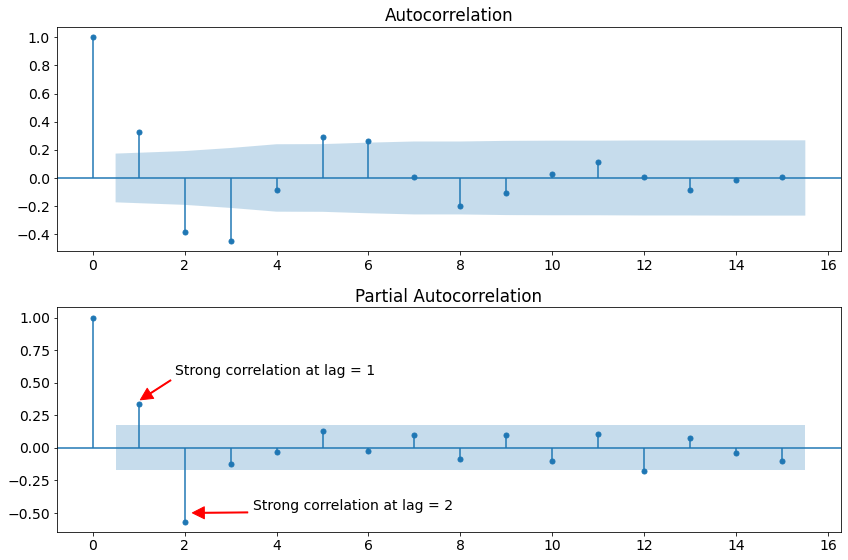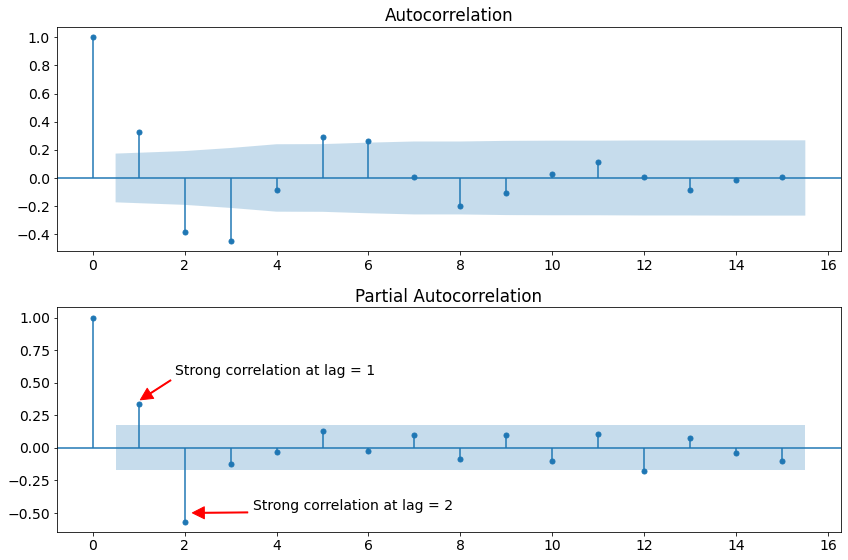)
- Industry Average: 1.50 to 1.60 -- [High Performance Computing vs Cloud Computing](https://www.totalcae.com/resources/high-performance-computing-vs-cloud-computing/)

**Why HPC Differs from Standard Data Centers**
- **Massive Rack Densities:** Standard server racks draw 5-10 kW, whereas HPC and AI can exceed 40-100 kW per rack. Traditional air cooling is highly inefficient at this scale
- **Liquid Cooling Requirements:** Because of extreme heat, most HPC systems rely on highly efficient liquid-to-chip or rear-door heat exchangers, whih dramatically lower cooling overhead and improve PUE
- **Full Utilization:** HPC clusters frequently run at 90-100% compute utilization, making the baseline denominator (IT equipment energy) very high, which positively skews the PUE ratio

In [65]:
combined_df.columns

Index(['ts', 'cooling_kw', 'hvac_kw', 'it_power_kw', 'plug_and_light_kw',
       'pue', 'pump_kw', 'day', 'outdoor_air_humidity', 'outdoor_air_temp',
       'pue_zscore'],
      dtype='object')

In [68]:
# Skew per feature
for col in ['cooling_kw', 'hvac_kw', 'it_power_kw', 
            'plug_and_light_kw', 'pue', 'pump_kw',
            'outdoor_air_temp', 'outdoor_air_humidity']:
    print(f'{col}: skew={combined_df[col].skew():.2f}')

cooling_kw: skew=4.96
hvac_kw: skew=3.36
it_power_kw: skew=1.88
plug_and_light_kw: skew=0.51
pue: skew=8.45
pump_kw: skew=1.00
outdoor_air_temp: skew=-0.18
outdoor_air_humidity: skew=0.71


**tldr:**
- I'm log transforming: cooling_kw, hvac_kw, it_power_kw



**Reasoning:**
Skew is saying that there is a visual representation of the bulk of the data in relation to its mean and extreme values. Depending on how looks goes then transforms are needed on some features so they are better suited prior to modeling. I won't transform pue because I'll predict that later. Otherwise, I'll transform the others is because others models make assumptions about the distribution of inputs. StandardScaler assumes data is roughly normally distributed. Heavily skewed features are in conflict with this thought. Log transforms pull the long right tail inward, so the distribution is more symmetric and closer to normal prior to scaling.

The rough rule of thumb:

- 0.5 to 0.5 — essentially symmetric, no transform needed
- 1 to -0.5 or 0.5 to 1 — moderate skew, StandardScaler handles it acceptably
- Below -1 or above 1 — high skew, consider log transform
- Above 2 or below -2 — severe skew, transform strongly recommended

In [69]:
# Correlation matrix
combined_df[['cooling_kw', 'hvac_kw', 'it_power_kw', 
             'plug_and_light_kw', 'pue', 'pump_kw',
             'outdoor_air_temp', 'outdoor_air_humidity']].corr()

# Outlier counts using pue_zscore
print(f'PUE outliers (|zscore| > 3): {(combined_df["pue_zscore"].abs() > 3).sum()}')

PUE outliers (|zscore| > 3): 784


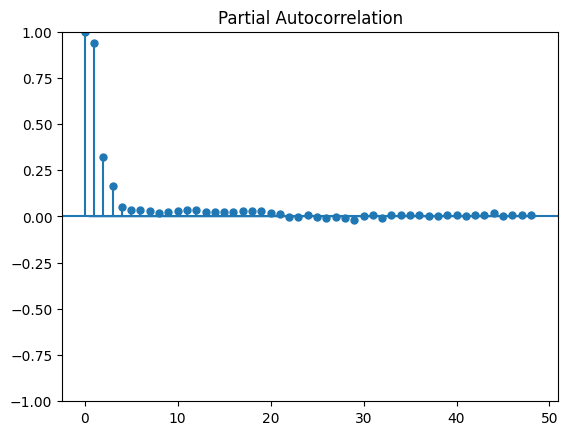

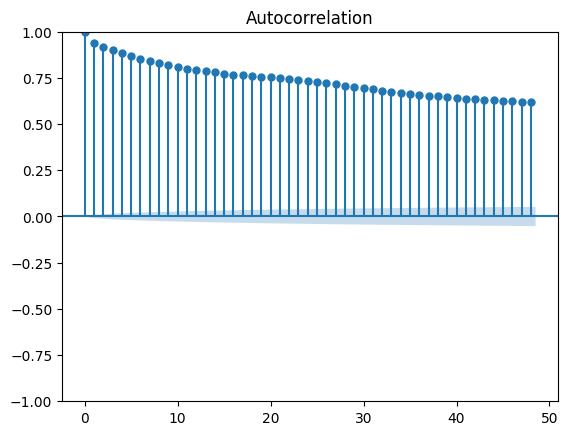

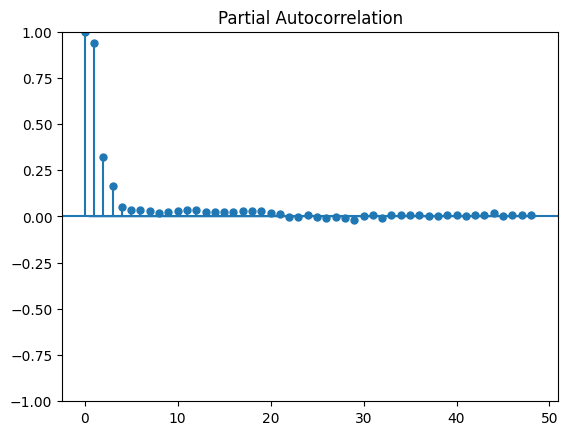

In [70]:
# ACF/PACF on hourly PUE
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(combined_df['pue'].dropna(), lags=48)
plot_pacf(combined_df['pue'].dropna(), lags=48)

- There is persistent autocorrelation at every lag from 1 to 50. The bars are basically all above the confidence band and decay is very slow. What was happening 48 hours ago is still predicting what happens now, which is good. 

- PACF shows strong spikes for the first two values and then it drops near 0 and hovers around that value. After the two most recent hours, the remaining values add little predictive power. 

- Good general signal for the LSTM for simple regression that I'll use later. The data has pretty strong temporal memory. PACF suggest the minimum sequence window should be at least 2 hours, but the slow-decaying ACF suggests a longer window to capture the full memory structure including daily patterns.

- Slow decay implies the PUE series may be non-stationary so it has a trend or persistent memory that doesn't decay quickly. LSTMs handle non-stationairty better than ARIMA models so it doesn't change the modeling approach too much. I'll use the LSTM architecture with a sequence window of at least 24 hours to capture daily operational cycles. Simple regression wouldn't capture this temporal structure.

In [73]:
# Final null check
print(combined_df.isnull().sum())
print('\n')
print(combined_df.shape)
print('\n')
print(combined_df.columns.tolist())

ts                         0
cooling_kw                 0
hvac_kw                 5628
it_power_kw                0
plug_and_light_kw       5628
pue                     5628
pump_kw                 5628
day                     5628
outdoor_air_humidity    5628
outdoor_air_temp           0
pue_zscore              5628
dtype: int64


(80773, 11)


['ts', 'cooling_kw', 'hvac_kw', 'it_power_kw', 'plug_and_light_kw', 'pue', 'pump_kw', 'day', 'outdoor_air_humidity', 'outdoor_air_temp', 'pue_zscore']


**Note**

- Done cleaning and analyzing. On to plotting, then modelling.

In [74]:
# Save
combined_df.drop(columns=['pue_zscore'], inplace = True)
combined_df.to_parquet('../data/pue_combined_hourly.parquet', index = False)
print(f'Saved: {len(combined_df):,} rows, {combined_df.shape[1]} columns')

Saved: 80,773 rows, 10 columns
